In [278]:
import importlib

from analysis import analysis_helpers
import datetime

from analysis.analysis_helpers import open_models

"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""
import logging
from datetime import datetime

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# PARAMETERS
classifications_csv_path = '../4_survey_responses/may-survey-classifications_2025-06-17.csv'
output_dir = '../media/'
prompts_path = '../1_input_prompts/prompts.json'
ml_responses_database_path = '../2_retrieved_responses/records.db'
subjects_path = '../4_survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845
exclude_prompts = [17]
exclude_models=['ollama_chat/deepseek-r1:8b'] # Deepseek-r1 was run with two inference platforms. We retain the results for the deepseek model with more parameters for a fair comparison

In [279]:
sns.set_theme(style="darkgrid")

In [280]:
current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

# Read classifications
classifications_df = pd.read_csv(classifications_csv_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)


In [281]:
importlib.reload(analysis_helpers)

combined_final = analysis_helpers.load_raw(classifications_csv_path, subjects_path, prompts_json_path=prompts_path, exclude_models=exclude_models, exclude_prompt_ids=exclude_prompts, workflow_id=workflow_id)

In [282]:
combined_final

,original_index,T1,T10,T11,T12,T2,T3,T4,T6,T7,...,response_id,#temperature,#llm_provider,#prompt_run_by,prompt_text,T2_score,T3_score,T4_score,T12_score,count_citations
0,637061162,[],,,No,3 - good,3 - good,Yes,No,"Correct answer, and good explanation",...,1,0.0,mistral,Artur,This question is about materials used to make ...,3,3,1,0,NaN
1,637477134,[],,,No,3 - good,3 - good,Yes,No,,...,16,0.0,mistral,Artur,Give a definition the functional unit of a pro...,3,3,1,0,NaN
2,638491212,[],,,No,3 - good,3 - good,Yes,No,"response is accurate, but a notice that the pr...",...,225,0.0,bedrock,bhabalaj,Most industrial processes produce more than th...,3,3,1,0,NaN
3,638512889,"[{'x': 478.4300537109375, 'y': 931.11059570312...","It uses appropiate language, however, as some ...",,Yes,1 - poor,2 - average,No,No,Some claims and numbers are wrong and not supp...,...,231,0.0,bedrock,bhabalaj,You a world class literature review writer. Yo...,1,2,0,1,11.0
4,638515924,"[{'x': 987.8692016601562, 'y': 209.98503112792...",,,No,2 - average,2 - average,Yes,No,"Generally correct, but misses information on t...",...,264,0.0,bedrock,bhabalaj,You are an LCA practitioner executing a study ...,2,2,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,640544574,[],,,No,4 - expert / better than human,3 - good,Yes,No,,...,177,0.0,bedrock,bhabalaj,Most industrial processes produce more than th...,4,3,1,0,NaN
164,640545460,[],,"I am not sure, wether the AI model knows to an...",Yes,1 - poor,1 - poor,Yes,Yes,,...,55,0.0,mistral,Artur,What multi-output allocation method should be ...,1,1,1,1,NaN
165,640545715,[],,,No,3 - good,3 - good,Yes,No,,...,250,0.0,bedrock,bhabalaj,Give a definition the functional unit of a pro...,3,3,1,0,NaN
166,640546144,[],,,No,2 - average,1 - poor,Yes,No,,...,59,0.0,gemini,Artur,You are an LCA practitioner executing a study ...,2,1,1,0,NaN


# Create summary for each question

In [283]:
combined_final.shape

(168, 36)

In [284]:
# Group combined_final by prompt_id and # llm_model
grouped_results = (combined_final
.groupby(['prompt_id', '#llm_model'])
.agg({
    'T2_score':'median',
    'T3_score':'median',
    'T4_score':'median',
    'T12_score':'median',
    'original_index':len})
.rename({
    'T2_score':'accuracy',
    'T3_score':'explanation',
    'T4_score':'format',
    'T12_score':'correct',
    'original_index':'count'
},axis=1))

In [285]:
grouped_results

accuracy  explanation  format  correct  count
prompt_id #llm_model                                                      
1         claude-3.7-sonnet       1.0          3.0     1.0      1.0      1
          deepseek-r1             2.0          4.0     1.0      1.0      1
          gemini-2.0-flash        2.0          4.0     1.0      1.0      1
          mistral-large           3.0          3.0     1.0      0.0      2
          qwen3                   4.0          4.0     1.0      0.0      1
...                               ...          ...     ...      ...    ...
24        llama4-maverick         4.0          1.0     1.0      1.0      1
          microsoft-phi4          2.5          2.5     1.0      0.0      2
          nova-premier-v1         3.0          3.0     1.0      0.0      3
          openai-gpt-4.1          3.0          3.0     1.0      0.0      1
          qwen3                   3.0          3.0     1.0      0.0      1

[124 rows x 5 columns]

In [286]:
grouped_results_2 = (combined_final
.groupby('#llm_model')
.agg({
    'T2_score':'median',
    'T3_score':'median',
    # 'T4_score':'median',
    # 'T12_score':'median',
    # 'original_index':len
})
.rename({
    'T2_score':'accuracy',
    'T3_score':'explanation',
    # 'T4_score':'format',
    # 'T12_score':'correct',
    # 'original_index':'count'
},axis=1))

mean_acc_expl = grouped_results_2.agg('median', axis=1)
grouped_results_2['median'] = mean_acc_expl
grouped_results_2

,accuracy,explanation,median
#llm_model,,,
claude-3.7-sonnet,2.5,3.0,2.75
deepseek-r1,2.0,2.0,2.00
gemini-2.0-flash,3.0,3.0,3.00
google-gemma3,2.0,3.0,2.50
llama4-maverick,2.5,3.0,2.75
llama4-scout,3.0,3.0,3.00
microsoft-phi4,3.0,3.0,3.00
mistral-large,2.5,3.0,2.75
nova-premier-v1,3.0,3.0,3.00


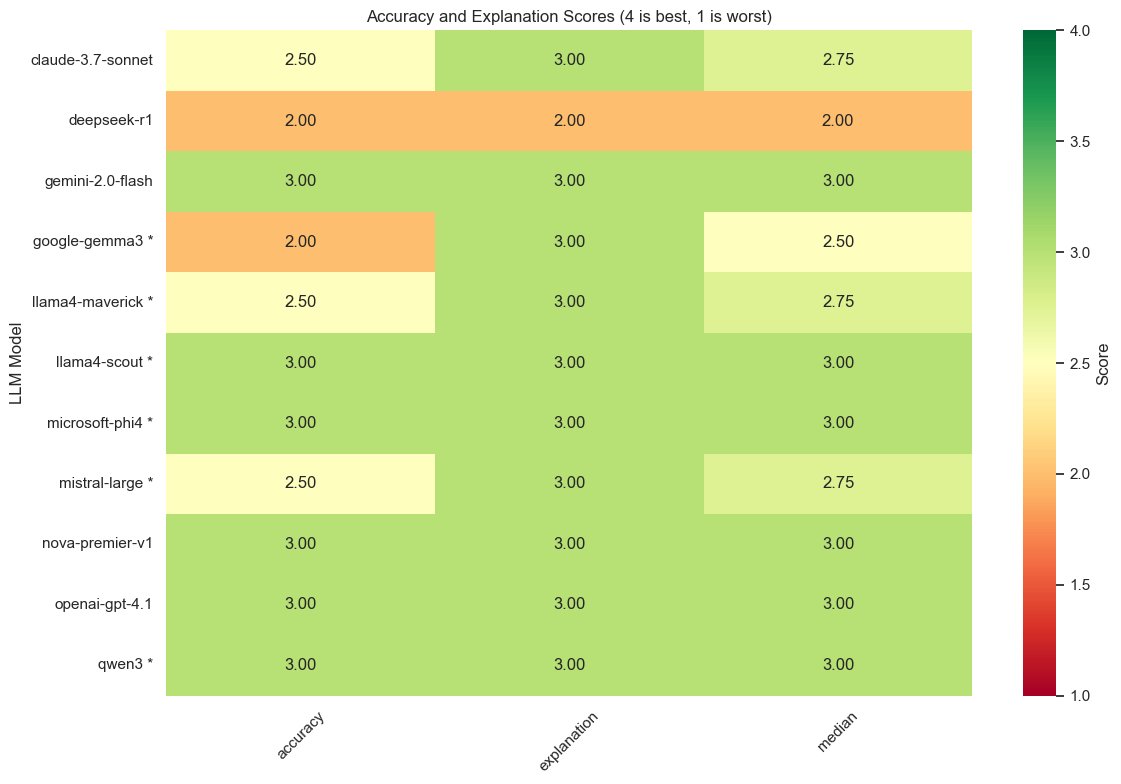

In [287]:
# Create a heatmap of grouped_results
plt.figure(figsize=(12, 8))

# Reset index to make prompt_id and #llm_model regular columns for easier plotting
grouped_results_reset = grouped_results_2.reset_index()
# Create the heatmap
ax = sns.heatmap(grouped_results_2, annot=True, cmap='RdYlGn', vmin=1, vmax=4, fmt='.2f',
            cbar_kws={'label': 'Score'})

plt.title('Accuracy and Explanation Scores (4 is best, 1 is worst)')
plt.xlabel('')
plt.ylabel('LLM Model')
plt.xticks(rotation=45)
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_yticklabels()]
plt.yticks(ax.get_yticks(), formatted_labels, rotation=0,ha='right')
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_heatmap_accuracy_and_explanation_median.png')
plt.show()


In [288]:
mean_acc_expl = grouped_results_2.agg('median',axis=1)
grouped_results_2['mean_acc_expl'] = mean_acc_expl


In [289]:
importlib.reload(analysis_helpers)

<module 'analysis.analysis_helpers' from 'Y:\\projects\\unep-life-cycle-assessment-ml-paper-evaluation\\analysis\\analysis_helpers.py'>

In [290]:
# filter combined_final where prompt_id is in the list `citation_prompts`create a bar chart showing the number of citations (length of the list in combined_final.T1) against the llm_model and prompt_id
citation_results = combined_final[combined_final.prompt_id.isin(analysis_helpers.citation_prompts)]
citation_results.loc[:,'count_citations'] = citation_results.T1.apply(len)


In [291]:
citation_results.count_citations.value_counts(dropna=False)

count_citations
0.0     35
1.0     13
5.0      6
6.0      5
2.0      4
3.0      3
11.0     1
10.0     1
4.0      1
12.0     1
Name: count, dtype: int64

In [292]:
citation_results.groupby('#llm_model').count_citations.count()

#llm_model
claude-3.7-sonnet    8
deepseek-r1          5
gemini-2.0-flash     1
google-gemma3        3
llama4-maverick      9
llama4-scout         3
microsoft-phi4       7
mistral-large        8
nova-premier-v1      9
openai-gpt-4.1       8
qwen3                9
Name: count_citations, dtype: int64

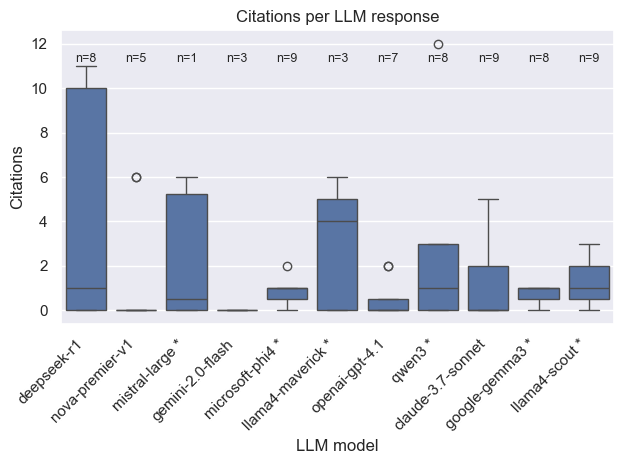

In [293]:
plt.figure()

citation_results.reset_index()
ax = sns.boxplot(citation_results,x='#llm_model',y='count_citations')
# plt.ylim(0, 7)
# Calculate counts per model
model_counts = citation_results.groupby('#llm_model').count_citations.count()

# Add text labels with counts
for i, (model, count) in enumerate(model_counts.items()):
    ax.text(i, ax.get_ylim()[1] * 0.92, f'n={count}',
            ha='center', va='top', fontweight='regular', fontsize=9)

plt.title('Citations per LLM response')
plt.xlabel('LLM model')
plt.ylabel('Citations')
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_boxplot_citations_per_llm_median.png')
plt.show()

# General summary

In [294]:
summary_binary_correct = combined_final.T12.value_counts()
summary_accuracy = combined_final.T2.value_counts()
summary_explanation = combined_final.T3.value_counts()
summary_format = combined_final.T4.value_counts() # does the response follow the expected format?

In [295]:
summary_binary_correct

T12
No     104
Yes     64
Name: count, dtype: int64

In [296]:
summary_accuracy

T2
3 - good                          77
2 - average                       46
1 - poor                          28
4 - expert / better than human    17
Name: count, dtype: int64

In [297]:
summary_explanation

T3
3 - good                          89
2 - average                       40
1 - poor                          20
4 - expert / better than human    19
Name: count, dtype: int64

In [298]:
summary_format

T4
Yes    136
No      32
Name: count, dtype: int64

In [299]:
grouped_results_2

,accuracy,explanation,median,mean_acc_expl
#llm_model,,,,
claude-3.7-sonnet,2.5,3.0,2.75,2.75
deepseek-r1,2.0,2.0,2.00,2.00
gemini-2.0-flash,3.0,3.0,3.00,3.00
google-gemma3,2.0,3.0,2.50,2.50
llama4-maverick,2.5,3.0,2.75,2.75
llama4-scout,3.0,3.0,3.00,3.00
microsoft-phi4,3.0,3.0,3.00,3.00
mistral-large,2.5,3.0,2.75,2.75
nova-premier-v1,3.0,3.0,3.00,3.00


In [300]:
combined_final

,original_index,T1,T10,T11,T12,T2,T3,T4,T6,T7,...,response_id,#temperature,#llm_provider,#prompt_run_by,prompt_text,T2_score,T3_score,T4_score,T12_score,count_citations
0,637061162,[],,,No,3 - good,3 - good,Yes,No,"Correct answer, and good explanation",...,1,0.0,mistral,Artur,This question is about materials used to make ...,3,3,1,0,NaN
1,637477134,[],,,No,3 - good,3 - good,Yes,No,,...,16,0.0,mistral,Artur,Give a definition the functional unit of a pro...,3,3,1,0,NaN
2,638491212,[],,,No,3 - good,3 - good,Yes,No,"response is accurate, but a notice that the pr...",...,225,0.0,bedrock,bhabalaj,Most industrial processes produce more than th...,3,3,1,0,NaN
3,638512889,"[{'x': 478.4300537109375, 'y': 931.11059570312...","It uses appropiate language, however, as some ...",,Yes,1 - poor,2 - average,No,No,Some claims and numbers are wrong and not supp...,...,231,0.0,bedrock,bhabalaj,You a world class literature review writer. Yo...,1,2,0,1,11.0
4,638515924,"[{'x': 987.8692016601562, 'y': 209.98503112792...",,,No,2 - average,2 - average,Yes,No,"Generally correct, but misses information on t...",...,264,0.0,bedrock,bhabalaj,You are an LCA practitioner executing a study ...,2,2,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,640544574,[],,,No,4 - expert / better than human,3 - good,Yes,No,,...,177,0.0,bedrock,bhabalaj,Most industrial processes produce more than th...,4,3,1,0,NaN
164,640545460,[],,"I am not sure, wether the AI model knows to an...",Yes,1 - poor,1 - poor,Yes,Yes,,...,55,0.0,mistral,Artur,What multi-output allocation method should be ...,1,1,1,1,NaN
165,640545715,[],,,No,3 - good,3 - good,Yes,No,,...,250,0.0,bedrock,bhabalaj,Give a definition the functional unit of a pro...,3,3,1,0,NaN
166,640546144,[],,,No,2 - average,1 - poor,Yes,No,,...,59,0.0,gemini,Artur,You are an LCA practitioner executing a study ...,2,1,1,0,NaN


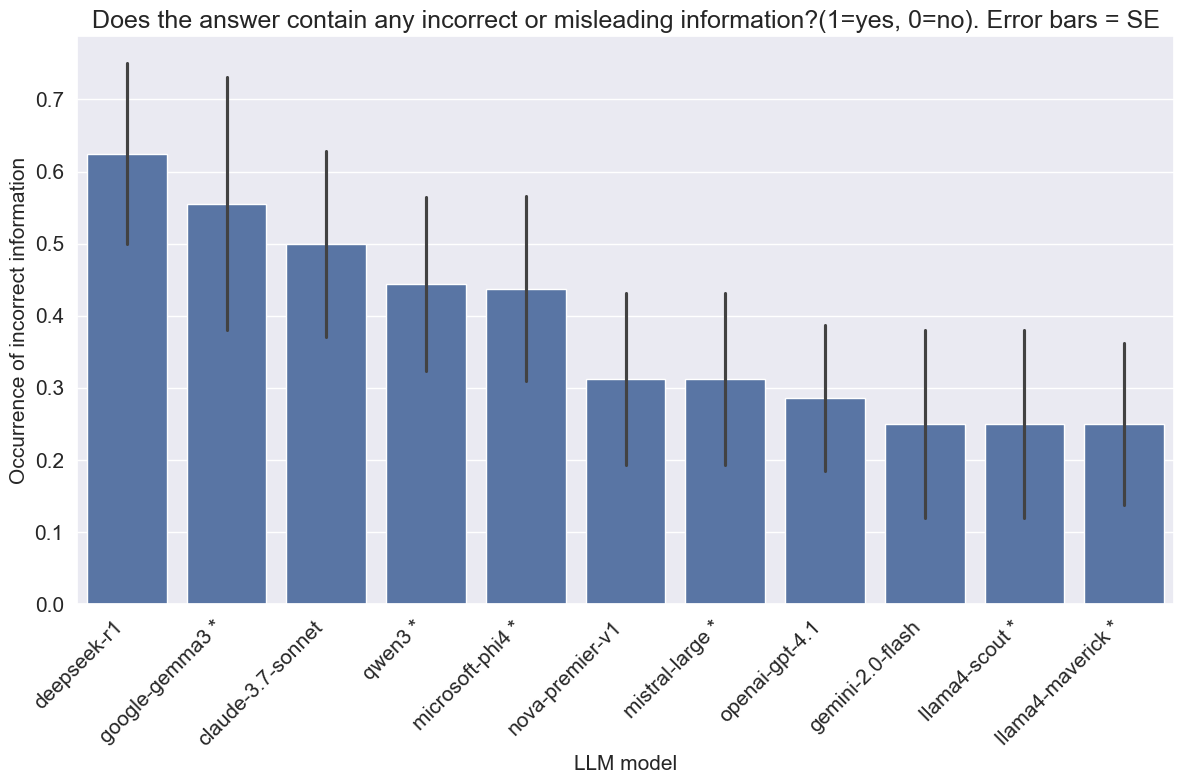

In [301]:
# Create a heatmap of grouped_results
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model').T12_score.mean().sort_values(ascending=False).index
# Reset index to make prompt_id and #llm_model regular columns for easier plotting
# grouped_results_reset = grouped_results.reset_index()
# Create the heatmap
ax = sns.barplot(combined_final, x='#llm_model', y='T12_score', errorbar=("se", 1),order=order)

plt.title(
    'Does the answer contain any incorrect or misleading information?(1=yes, 0=no). Error bars = SE',
    fontsize=18)
plt.xlabel('LLM model', fontsize=15)
plt.ylabel('Occurrence of incorrect information', fontsize=15)
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right',fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_incorrect_per_llm_median.png')
plt.show()


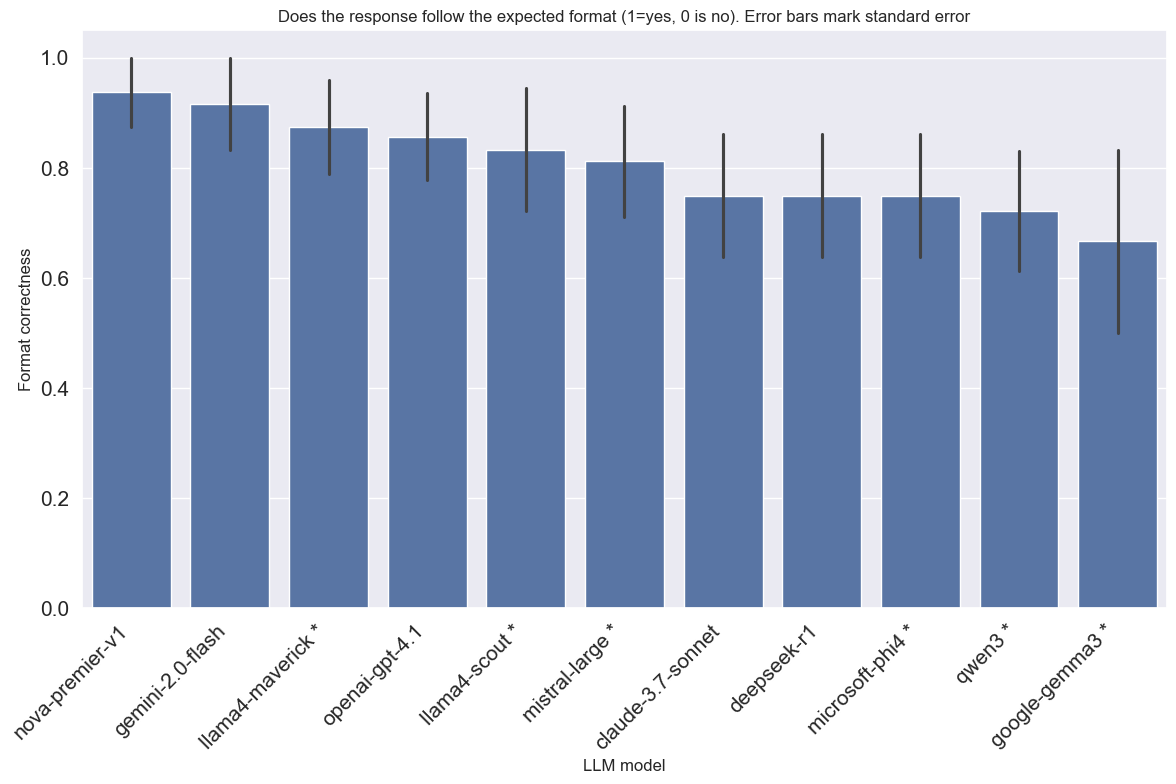

In [302]:

# Create a heatmap of grouped_results
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model').T4_score.mean().sort_values(ascending=False).index

# Reset index to make prompt_id and #llm_model regular columns for easier plotting
# grouped_results_reset = grouped_results.reset_index()
# Create the heatmap
ax = sns.barplot(combined_final, x='#llm_model', y='T4_score',errorbar=("se",1),order=order)#, cmap='RdYlGn', fmt='.2f')

plt.title('Does the response follow the expected format (1=yes, 0 is no). Error bars mark standard error')
plt.xlabel('LLM model')
plt.ylabel('Format correctness')
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right', fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_format_per_llm_median.png')
plt.show()


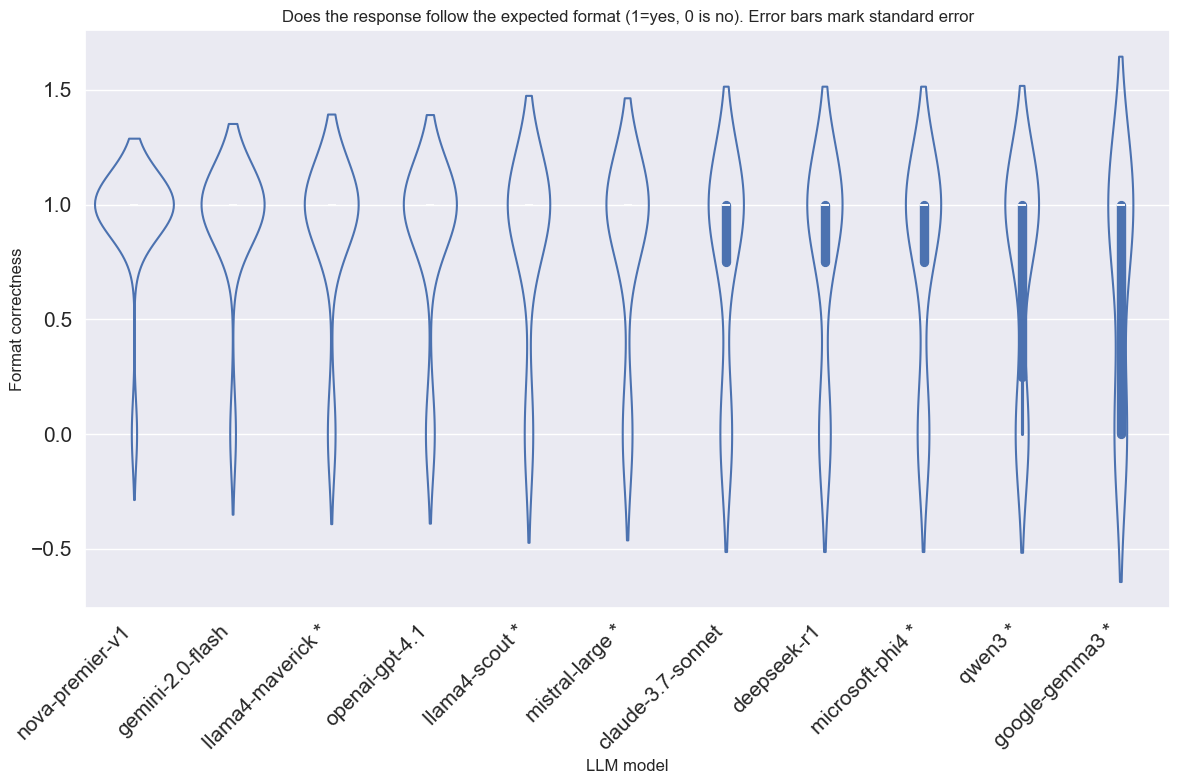

In [303]:

# Create a heatmap of grouped_results
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model').T4_score.mean().sort_values(ascending=False).index

# Reset index to make prompt_id and #llm_model regular columns for easier plotting
# grouped_results_reset = grouped_results.reset_index()
# Create the heatmap
ax = sns.violinplot(combined_final, x='#llm_model', y='T4_score',fill=False, order=order)#, cmap='RdYlGn', fmt='.2f')

plt.title('Does the response follow the expected format (1=yes, 0 is no). Error bars mark standard error')
plt.xlabel('LLM model')
plt.ylabel('Format correctness')
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right', fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_violinchart_format_per_llm_median.png')
plt.show()


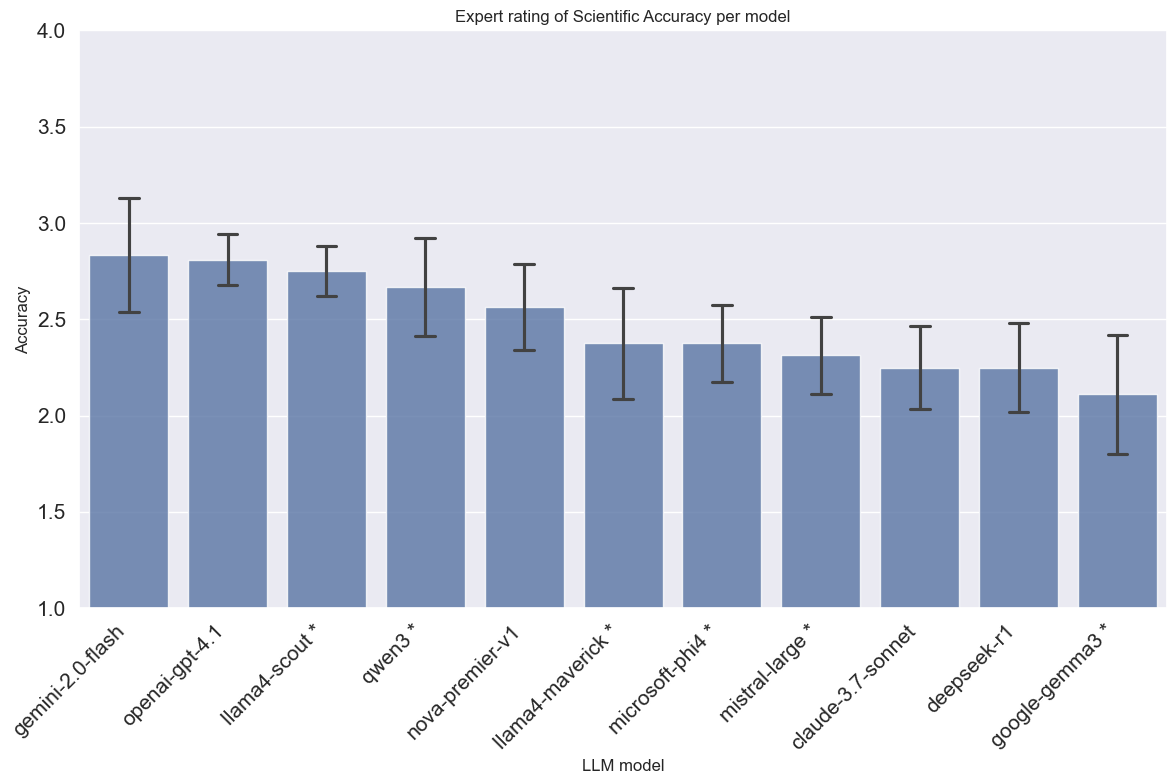

In [304]:
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model')['T2_score'].mean().sort_values(ascending=False).index

# Reset index to make prompt_id and #llm_model regular columns for easier plotting
# grouped_results_reset = grouped_results.reset_index()
# Create the heatmap
ax = sns.barplot(combined_final, x='#llm_model', y='T2_score',errorbar=("se",1), capsize=0.2, alpha=0.8, order=order)#, cmap='RdYlGn', fmt='.2f')

plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('LLM model')
plt.ylabel('Accuracy')
plt.ylim(1,4)
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right',fontsize=15)
plt.yticks(rotation=0,fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_accuracy_per_llm_median.png')
plt.show()


In [305]:
accuracy_df

,mean,sem
#llm_model,,
llama4-scout,3.166667,0.207194
openai-gpt-4.1,2.761905,0.167684
gemini-2.0-flash,2.750000,0.350865
nova-premier-v1,2.750000,0.193649
claude-3.7-sonnet,2.687500,0.198300
google-gemma3,2.666667,0.166667
microsoft-phi4,2.625000,0.154785
mistral-large,2.562500,0.181860
llama4-maverick,2.562500,0.203485


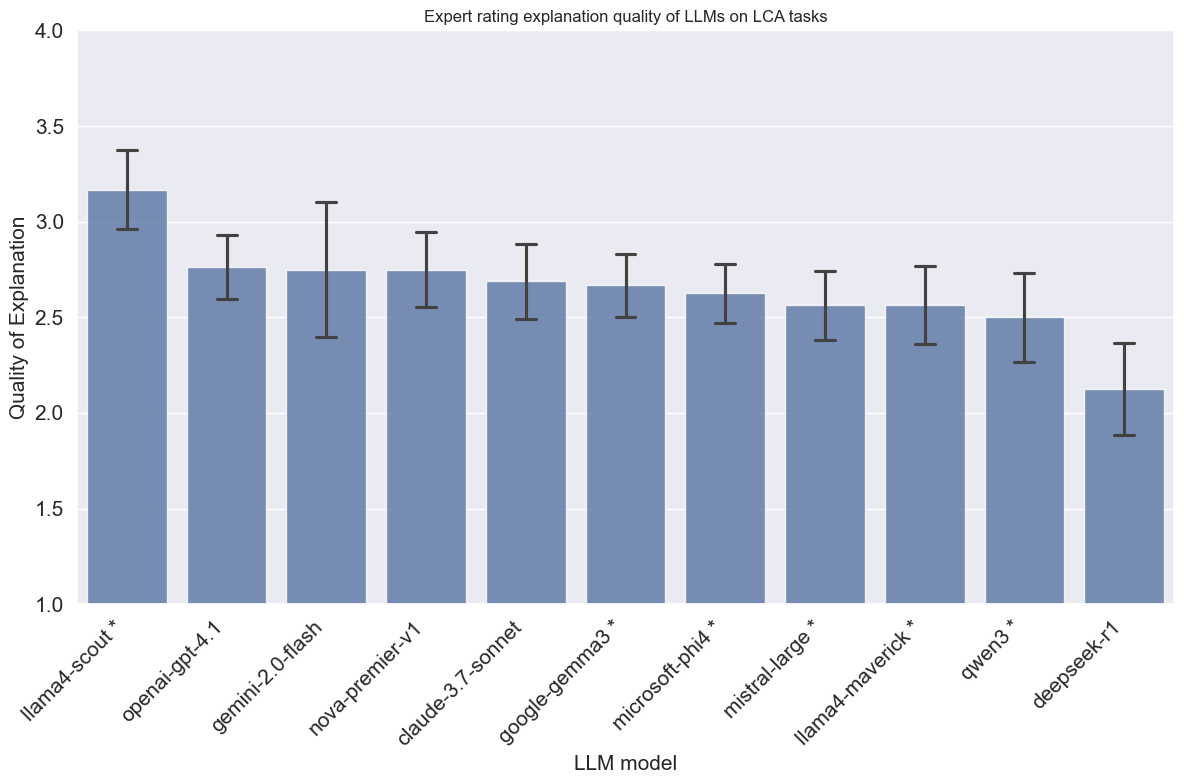

In [306]:
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model')['T3_score'].mean().sort_values(ascending=False).index
accuracy_df = combined_final.groupby('#llm_model')['T3_score'].agg(['median','sem']).sort_values('median',ascending=False)
x_pos = range(accuracy_df.shape[0])
ax = sns.barplot(combined_final, x='#llm_model',y='T3_score', errorbar=('se',1), capsize=0.2, alpha=0.8,order=order)#, cmap='RdYlGn', fmt='.2f')

plt.title('Expert rating explanation quality of LLMs on LCA tasks')
plt.ylim(1,4)
plt.xlabel('LLM model',fontsize=15)
plt.ylabel('Quality of Explanation',fontsize=15)
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right',fontsize=15)
plt.yticks(rotation=0,fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_explanation_per_llm_median.png')
plt.show()


In [307]:
# Plot accuracy and explanation side-by-side on the same set of axes

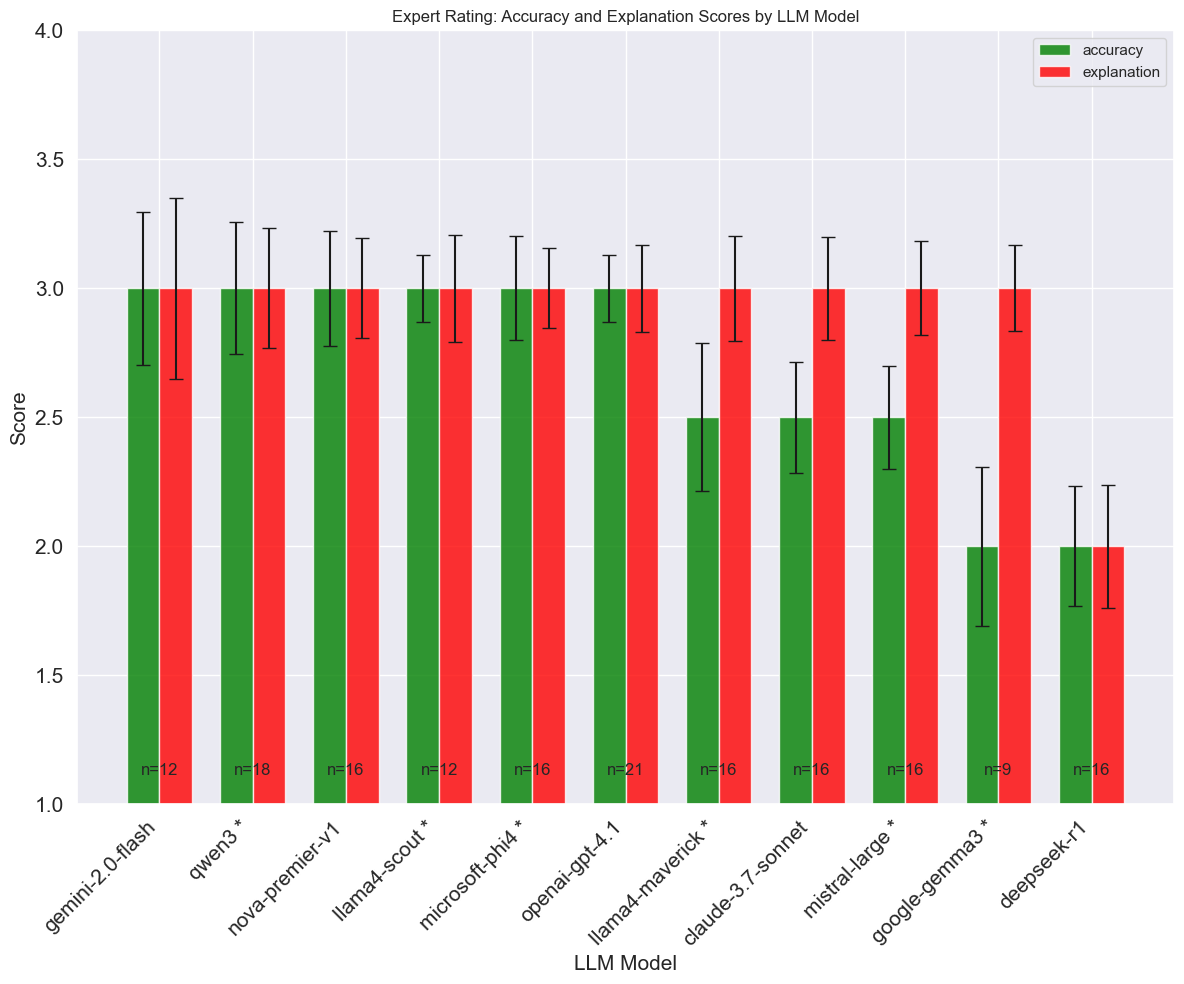

In [308]:
import numpy as np
fig = plt.figure(figsize=(12, 10))

# Calculate means and standard errors
grouped_results_3 = (combined_final
.groupby('#llm_model')
.agg({
    'T2_score':['median','sem'],
    'T3_score':['median','sem'],
    # 'T4_score':'median',
    # 'T12_score':'median',
    # 'original_index':len
})
.rename({
    'T2_score':'accuracy',
    'T3_score':'explanation',
    # 'T4_score':'format',
    # 'T12_score':'correct',
    # 'original_index':'count'
},axis=1))

t2_stats = grouped_results_3['accuracy']
t3_stats = grouped_results_3['explanation']

mean_acc_expl = grouped_results_3[['accuracy','explanation']].agg('median', axis=1) # TODO: Fix aggregation to only take the mean values of accuract and explanation (at the moment it is also getting the sem values)
grouped_results_3.loc[:,'mean_acc_expl'] = mean_acc_expl
order = mean_acc_expl.sort_values(ascending=False).index

# Order by T2_score mean
t2_stats = t2_stats.loc[order]
t3_stats = t3_stats.loc[order]


# Set up bar positions
x = np.arange(len(order))
width = 0.35

# Create bars
bars1 = plt.bar(x - width/2, t2_stats['median'], width, yerr=t2_stats['sem'], label='accuracy', color='green', alpha=0.8, capsize=5)
bars2 = plt.bar(x + width/2, t3_stats['median'], width, yerr=t3_stats['sem'], label='explanation', color='red', alpha=0.8, capsize=5)

plt.xlabel('LLM Model', fontsize=15)
plt.ylabel('Score', fontsize=15)
plt.ylim(1,4)
plt.title('Expert Rating: Accuracy and Explanation Scores by LLM Model')
ax = fig.get_axes()[0]
for i, llm_model in enumerate(order):
    count = combined_final[combined_final['#llm_model'] == llm_model]['T2_score'].count()
    standard_error_t2 = t2_stats.loc[llm_model,'sem']
    standard_error_t3 = t3_stats.loc[llm_model,'sem']
    plt.text(x[i], ax.get_ylim()[0] + 0.1, f'n={count:.0f}', ha='center', va='bottom', fontsize=12)
    # plt.text(x[i], ax.get_ylim()[0] + 0.5, f'acc sd={standard_error_t2:.2f}', ha='center', va='bottom', fontsize=10)
    # plt.text(x[i], ax.get_ylim()[0] + 0.3, f'exp sd={standard_error_t3:.2f}', ha='center', va='bottom', fontsize=10)
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label) for label in order]
plt.xticks(x, order, rotation=45, ha='right')
plt.xticks(ticks=x,labels=formatted_labels,rotation=45,ha='right',fontsize=15)
plt.yticks(fontsize=15)
plt.legend()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.tight_layout()

plt.savefig(output_dir / f'{datestamp}_barchart_accuracy_explanation_median.png')
plt.show()


In [309]:
mean_acc_expl
grouped_results_3

accuracy           explanation           mean_acc_expl
                    median       sem      median       sem              
#llm_model                                                              
claude-3.7-sonnet      2.5  0.214087         3.0  0.198300      1.357044
deepseek-r1            2.0  0.232737         2.0  0.239357      1.119678
gemini-2.0-flash       3.0  0.297294         3.0  0.350865      1.675432
google-gemma3          2.0  0.309320         3.0  0.166667      1.154660
llama4-maverick        2.5  0.286865         3.0  0.203485      1.393433
llama4-scout           3.0  0.130558         3.0  0.207194      1.603597
microsoft-phi4         3.0  0.201556         3.0  0.154785      1.600778
mistral-large          2.5  0.198300         3.0  0.181860      1.349150
nova-premier-v1        3.0  0.223024         3.0  0.193649      1.611512
openai-gpt-4.1         3.0  0.131277         3.0  0.167684      1.583842
qwen3                  3.0  0.255655         3.0  0.232210      1.627827

In [310]:
type(grouped_results_3['accuracy'])

pandas.core.frame.DataFrame

In [311]:
grouped_results_3.to_csv('accuracy_explanation_scores_with_variance.csv',float_format = "%0.3f")

In [312]:
llm_model
t2_stats.loc[llm_model,'sem']

np.float64(0.2327373340628157)

|# Test Inter-Rater Reliability

In [313]:
classifications_df = pd.read_csv(classifications_csv_path)
classifications_df = analysis_helpers._filter_logged_in_users(classifications_df)

In [314]:
classifications_df

,classification_id,user_name,user_id,user_ip,workflow_id,workflow_name,workflow_version,created_at,gold_standard,expert,metadata,annotations,subject_data,subject_ids
0,637061162,artur-lca,2855607.0,03887b80781b698b0ece,28845,May Survey,1.1,2025-05-06 17:41:44 UTC,NaN,NaN,"{""source"":""api"",""session"":""30991c51b15784fd2ed...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220415"":{""retired"":null,""#date_run"":""2025...",109220415
1,637477134,artur-lca,2855607.0,584746693c9022a4d0fe,28845,May Survey,1.1,2025-05-08 06:33:22 UTC,NaN,NaN,"{""source"":""api"",""session"":""eaf32200486c3dfe0f4...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220647"":{""retired"":null,""#date_run"":""2025...",109220647
7,638491212,NicolasH.,2871905.0,976deb71ab8935a2538b,28845,May Survey,1.1,2025-05-12 13:05:38 UTC,NaN,NaN,"{""source"":""api"",""session"":""019c98980731646c7dc...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220640"":{""retired"":{""id"":140884037,""workf...",109220640
8,638512889,NicolasH.,2871905.0,8b46272ba49b1b14af3a,28845,May Survey,1.1,2025-05-12 14:05:20 UTC,NaN,NaN,"{""source"":""api"",""session"":""019c98980731646c7dc...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220444"":{""retired"":null,""#date_run"":""2025...",109220444
9,638515924,NicolasH.,2871905.0,1e71501358ae61444bb2,28845,May Survey,1.1,2025-05-12 14:12:45 UTC,NaN,NaN,"{""source"":""api"",""session"":""019c98980731646c7dc...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220557"":{""retired"":null,""#date_run"":""2025...",109220557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,640544574,NicolasH.,2871905.0,ea5355e09c8ebc41caf2,28845,May Survey,1.1,2025-05-19 15:17:54 UTC,NaN,NaN,"{""source"":""api"",""session"":""aeacb21fd1c270e49ba...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220639"":{""retired"":null,""#date_run"":""2025...",109220639
201,640545460,NicolasH.,2871905.0,ce76499b631eab6aee1f,28845,May Survey,1.1,2025-05-19 15:20:42 UTC,NaN,NaN,"{""source"":""api"",""session"":""aeacb21fd1c270e49ba...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220522"":{""retired"":null,""#date_run"":""2025...",109220522
202,640545715,NicolasH.,2871905.0,ce76499b631eab6aee1f,28845,May Survey,1.1,2025-05-19 15:21:22 UTC,NaN,NaN,"{""source"":""api"",""session"":""aeacb21fd1c270e49ba...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220653"":{""retired"":{""id"":140883835,""workf...",109220653
203,640546144,NicolasH.,2871905.0,ce76499b631eab6aee1f,28845,May Survey,1.1,2025-05-19 15:22:22 UTC,NaN,NaN,"{""source"":""api"",""session"":""aeacb21fd1c270e49ba...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220551"":{""retired"":null,""#date_run"":""2025...",109220551


In [315]:
exclude_prompt_ids=[17]

subjects_df = pd.read_csv(subjects_path)
# Extract the prompt_id, llm model and other data from the metadata column
subjects_df = subjects_df.loc[subjects_df.workflow_id == workflow_id]
metadata_df = subjects_df['metadata'].apply(json.loads).apply(pd.Series)
subjects_df = pd.concat([subjects_df, metadata_df], axis=1)

# Apply filters
subjects_df = analysis_helpers._filter_by_models(subjects_df, exclude_models)
subjects_df = analysis_helpers._filter_by_prompt_ids(subjects_df, exclude_prompt_ids)


In [316]:
exploded_dfs = classifications_df['annotations'].apply(analysis_helpers.explode_tasks)
exploded_df = pd.concat(
    exploded_dfs.values,
    keys=exploded_dfs.index,
    names=['original_index', 'task_index']
).reset_index(level='task_index', drop=True)

# Pivot the DataFrame to have one column per task
pivoted_df = exploded_df.pivot(columns='task', values='value').reset_index()
# Re-insert the classification_ids and user_id
pivoted_df['subject_id'] = classifications_df.loc[
    pivoted_df['original_index'], 'subject_ids'
].values
pivoted_df['user_id'] = classifications_df.loc[
    pivoted_df['original_index'], 'user_id'
].values

# Merge and set dtype of prompt_id
combined_df_with_user_id = pivoted_df.merge(subjects_df, on='subject_id', how='inner')
combined_df_with_user_id.prompt_id = combined_df_with_user_id.prompt_id.astype(int)
analysis_helpers._map_scores(combined_df_with_user_id)

In [317]:
combined_df_with_user_id.user_id.value_counts(dropna=False)

user_id
2874233.0    50
2871905.0    20
2872077.0    15
2875376.0    13
2872047.0    12
2874235.0     9
2871772.0     8
2863462.0     8
2855607.0     7
2872141.0     7
2868207.0     6
2874251.0     5
2864613.0     2
2874226.0     2
2874780.0     2
2875535.0     1
2883567.0     1
Name: count, dtype: int64

In [318]:
combined_df_with_user_id.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'user_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'T2_score', 'T3_score', 'T4_score',
       'T12_score'],
      dtype='object')

In [319]:
# Create concatenated column and set as index
df_temp = combined_df_with_user_id[['prompt_id','subject_id','user_id', '#llm_model', 'T3_score']].copy()
# Pivot with user_id as rows and subject_id as columns
pivoted_df = df_temp.pivot_table(index='user_id', columns='subject_id', values='T3_score', aggfunc='median')
pivoted_df.loc[:,'Counts']= pivoted_df.count(axis=1)
pivoted_df.sort_values('Counts',ascending=False,inplace=True)


## Examine the number of ratings per subject

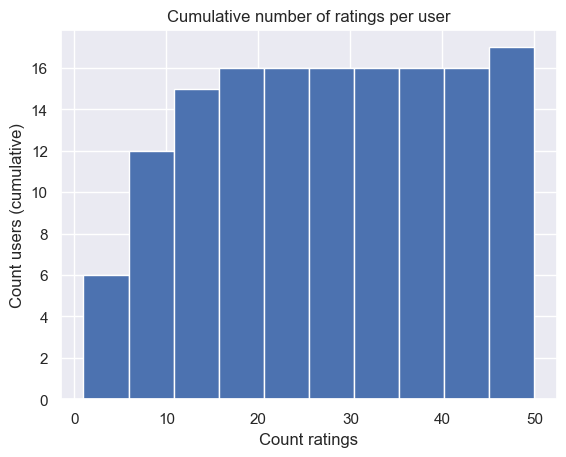

In [320]:
plt.figure()
pivoted_df.Counts.hist(cumulative=True)
plt.title('Cumulative number of ratings per user')
plt.ylabel('Count users (cumulative)')
plt.xlabel('Count ratings')
plt.show()

# Examine  number of ratings per subject

In [321]:
counts_per_subject = pivoted_df.count(axis=0)
counts_per_subject.sort_values(ascending=False)

subject_id
Counts       17
109220615     3
109220692     3
109220603     3
109220686     3
             ..
109220668     1
109220690     1
109220689     1
109220691     1
109220694     1
Length: 125, dtype: int64

In [322]:

subjects_to_include = list(counts_per_subject[counts_per_subject>2].drop('Counts').index.values)
subjects_to_include

[109220603, 109220615, 109220640, 109220675, 109220683, 109220686, 109220692]

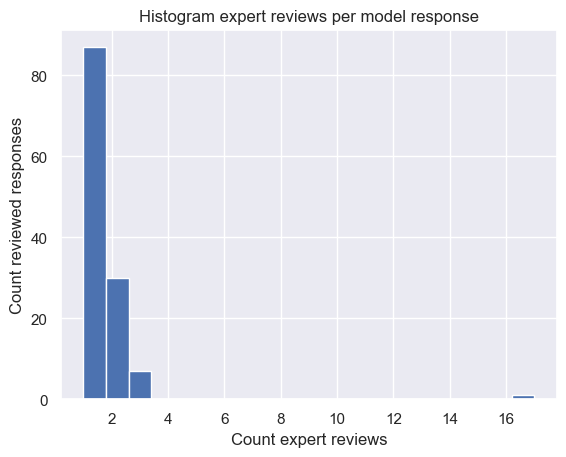

In [323]:
plt.figure()
counts_per_subject.hist(bins=20)
plt.title('Histogram expert reviews per model response')
plt.ylabel('Count reviewed responses')
plt.xlabel('Count expert reviews')
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_heatmap_accuracy_and_explanation_median.png')
plt.show()

In [324]:
nullmask = '-'
ratings_q3 = pivoted_df.fillna(nullmask).to_dict('records')

We now have the ratings for each rater in a form we can use with the krippendorf_alpha scripts

In [325]:
ratings_q3

[{109220415: '-',
  109220416: 4.0,
  109220418: 3.0,
  109220420: 4.0,
  109220424: '-',
  109220427: '-',
  109220429: 4.0,
  109220435: '-',
  109220436: '-',
  109220439: '-',
  109220442: 2.0,
  109220443: 3.0,
  109220444: '-',
  109220445: '-',
  109220450: '-',
  109220452: '-',
  109220453: 3.0,
  109220456: '-',
  109220457: '-',
  109220462: '-',
  109220464: '-',
  109220468: '-',
  109220469: '-',
  109220477: 3.0,
  109220478: '-',
  109220480: 1.0,
  109220483: 3.0,
  109220484: 3.0,
  109220500: 3.0,
  109220501: '-',
  109220503: '-',
  109220505: '-',
  109220507: 2.0,
  109220516: '-',
  109220517: '-',
  109220519: 3.0,
  109220521: 3.0,
  109220522: '-',
  109220523: '-',
  109220524: '-',
  109220525: 3.0,
  109220527: '-',
  109220529: 4.0,
  109220532: 3.0,
  109220536: '-',
  109220538: 1.0,
  109220539: '-',
  109220540: '-',
  109220543: '-',
  109220546: '-',
  109220550: 2.0,
  109220551: '-',
  109220552: '-',
  109220555: '-',
  109220557: '-',
  10922055

In [326]:
from krippendorf_alpha import krippendorff_alpha, nominal_metric,interval_metric, ratio_metric
import numpy as np

krippendorf_q3 = krippendorff_alpha(ratings_q3, ratio_metric, missing_items=nullmask)

In [327]:
f'{krippendorf_q3:.3g}'

'0.219'